In [1]:
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.plotting import plot_lifetimes
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_excel('new_data_set.xlsx')

columns_to_check= ['dauer', 'zn_myasthener_krise', 'sex', 'seronegative']

df_original= df[columns_to_check]
df_original.head()


,dauer,zn_myasthener_krise,sex,seronegative
0,17.377778,1,0,0.0
1,3.961111,0,1,0.0
2,2.677778,0,1,0.0
3,0.338889,0,1,0.0
4,18.902778,0,0,0.0


<Axes: >

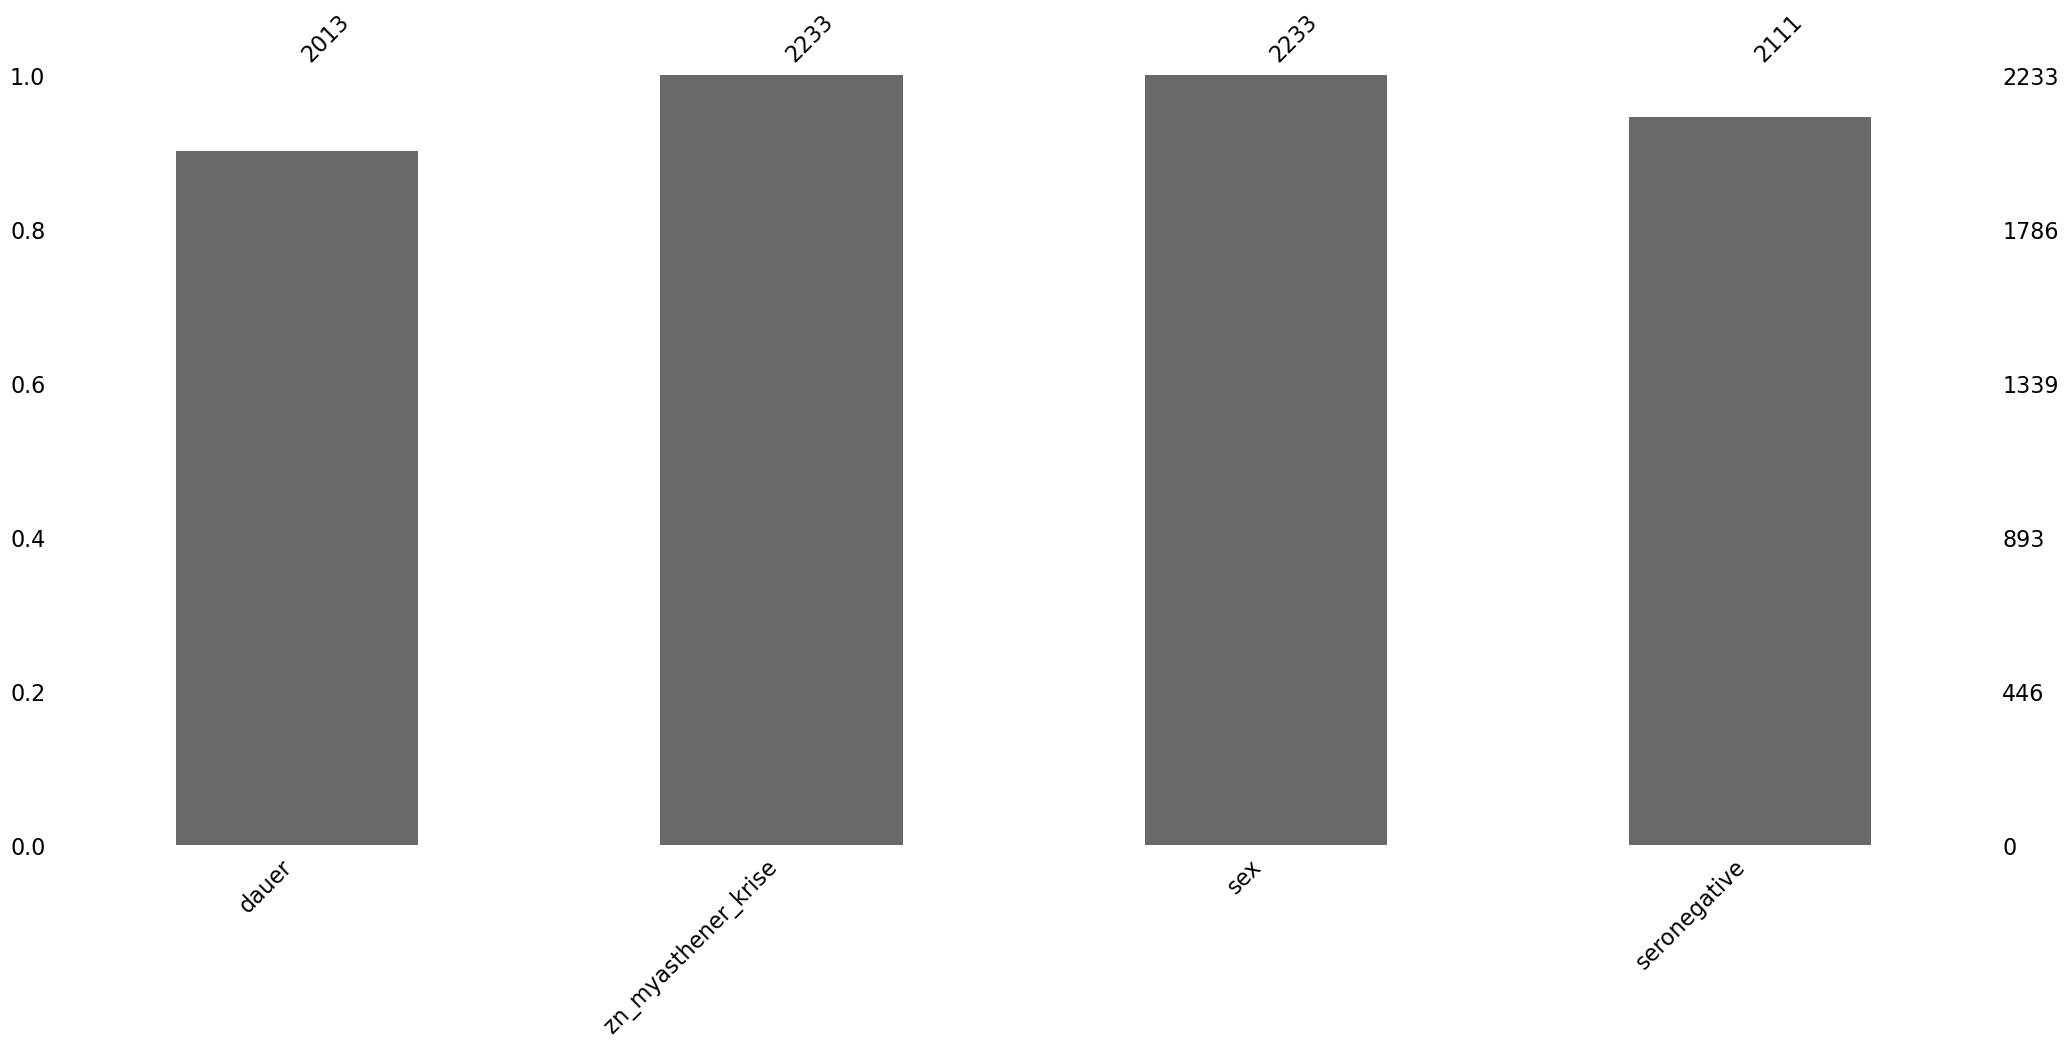

In [3]:
import missingno as msno 

msno.bar(df_original)

In [4]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.tree import DecisionTreeRegressor

# Define the columns
continuous_columns = ['dauer']
categorical_columns = ['seronegative']

# Custom function for rounding categorical variables
def round_categorical(imputed_data, categorical_columns):
    imputed_data[categorical_columns] = imputed_data[categorical_columns].round().astype(int)
    return imputed_data

# Custom function to enforce non-negative values on continuous columns
def enforce_non_negative(df, continuous_columns):
    df[continuous_columns] = df[continuous_columns].applymap(lambda x: max(x, 0))
    return df

In [5]:
# Tune DecisionTreeRegressor
dt_estimator = DecisionTreeRegressor(max_depth=20,        
                                     min_samples_split=5, 
                                     min_samples_leaf=3,
                                     random_state=0)

# Initialize the MICE imputer with tuned DecisionTreeRegressor
mice_imputer = IterativeImputer(estimator=dt_estimator, 
                                max_iter=30,  
                                random_state=0, 
                                tol=1e-4,  
                                n_nearest_features=10,  
                                initial_strategy='median')

In [6]:
# Fit and transform the dataset
df_imputed = mice_imputer.fit_transform(df_original)

# Convert the imputed result back to a DataFrame
df_imputed = pd.DataFrame(df_imputed, columns=df_original.columns)

# Apply rounding to categorical variables
df_imputed = round_categorical(df_imputed, categorical_columns)

# Enforce non-negative values
df_imputed = enforce_non_negative(df_imputed, continuous_columns)

# Output the imputed dataset
df_imputed_dataset = df_imputed
df_imputed_dataset.head()

,dauer,zn_myasthener_krise,sex,seronegative
0,17.377778,1.0,0.0,0
1,3.961111,0.0,1.0,0
2,2.677778,0.0,1.0,0
3,0.338889,0.0,1.0,0
4,18.902778,0.0,0.0,0


In [7]:
df_imputed_dataset.isnull().sum()

dauer                  0
zn_myasthener_krise    0
sex                    0
seronegative           0
dtype: int64

In [8]:
# Variables for Kaplan-Meier Survival Analysis

time_column = 'dauer'
event_column = 'zn_myasthener_krise'
group_columns = ['sex', 'seronegative']

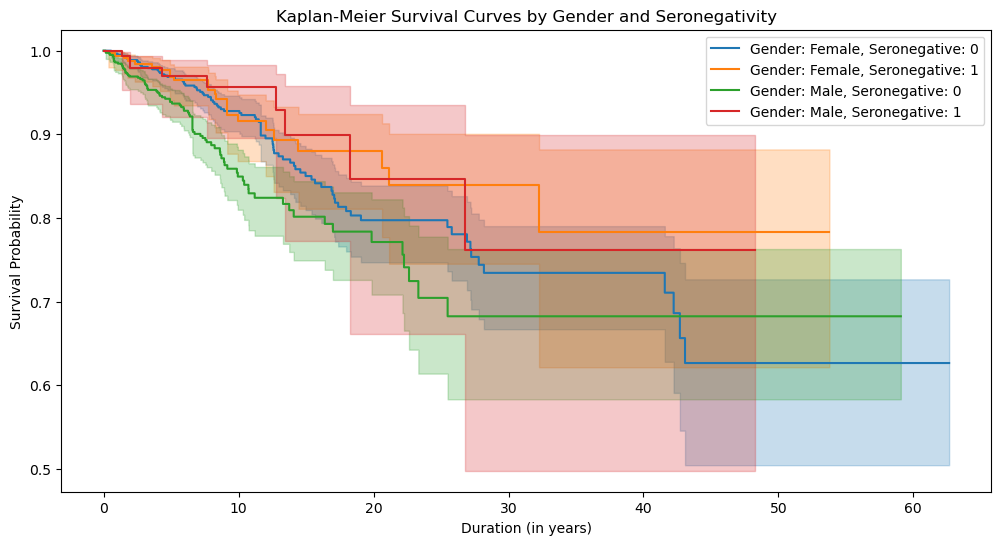

In [9]:
# Initialize Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Plot survival curves by groups
plt.figure(figsize=(12, 6))

# Iterate over groups
for name, grouped_df in df_imputed_dataset.groupby(group_columns):
    gender = 'Female' if name[0] == 0 else 'Male'
    label = f'Gender: {gender}, Seronegative: {name[1]}'
    kmf.fit(durations=grouped_df[time_column], event_observed=grouped_df[event_column], label=label)
    kmf.plot_survival_function()

plt.title('Kaplan-Meier Survival Curves by Gender and Seronegativity')
plt.xlabel('Duration (in years)')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

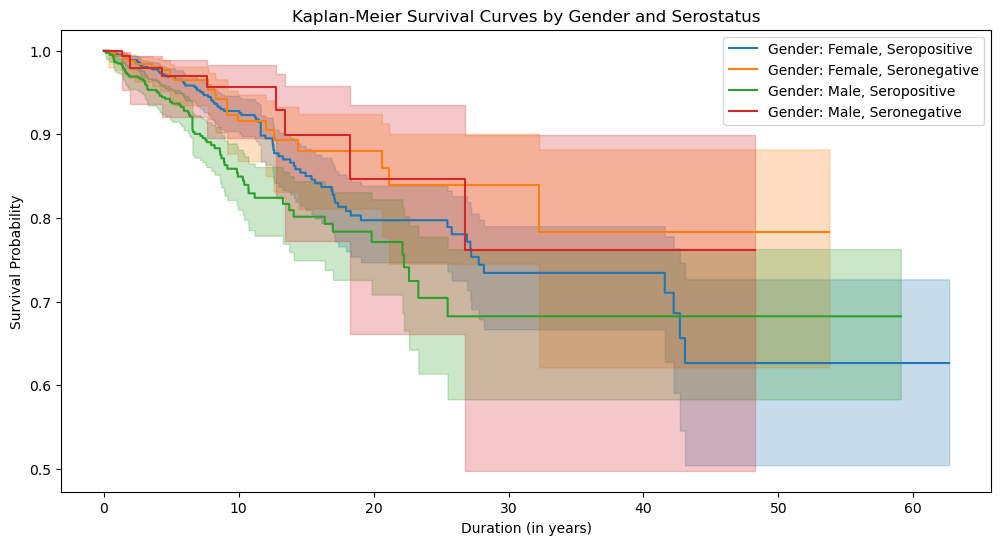

In [10]:
# Initialize Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Plot survival curves by groups
plt.figure(figsize=(12, 6))

# Iterate over groups and plot each
for name, grouped_df in df_imputed_dataset.groupby(group_columns):
    gender = 'Female' if name[0] == 0 else 'Male'
    serostatus = 'Seronegative' if name[1] == 1 else 'Seropositive'
    label = f'Gender: {gender}, {serostatus}'
    kmf.fit(
        durations=grouped_df[time_column],
        event_observed=grouped_df[event_column],
        label=label
    )
    kmf.plot_survival_function()

plt.title('Kaplan-Meier Survival Curves by Gender and Serostatus')
plt.xlabel('Duration (in years)')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()